# Análisis de las reseñas de memorias RAM

En este notebook se analizará el texto de las reseñas de memorias RAM guardadas en PostgreSQL.

El objetivo es:

- Preparar y limpiar el texto de las reseñas.
- Revisar las palabras que aparecen con más frecuencia.
- Separar las reseñas en positivas, neutras y negativas.
- Preparar estos resultados para utilizarlos más adelante en la aplicación.

In [1]:
import pandas as pd
import psycopg

password = input("Contraseña PostgreSQL: ")

conn = psycopg.connect(
    dbname="pccomponentes_ml",
    user="postgres",
    password=password,
    host="localhost",
    port=5432,
)

conn.execute("SET TRANSACTION READ ONLY")

print("Conexión de solo lectura creada correctamente")

Conexión de solo lectura creada correctamente


In [2]:
def consultar_dataframe(consulta):
    with conn.cursor() as cursor:
        cursor.execute(consulta)

        columnas = [columna.name for columna in cursor.description]

        registros = cursor.fetchall() 

    return pd.DataFrame(registros, columns=columnas)

resenas = consultar_dataframe("""
    SELECT
        r.resena_id,
        r.producto_id,
        p.nombre,
        r.valoracion,
        r.texto_resena,
        r.pros,
        r.contras
    FROM resenas AS r
    INNER JOIN productos AS p
        ON r.producto_id = p.producto_id
    WHERE p.categoria = 'memoria_ram'
    ORDER BY r.producto_id, r.resena_id;
""")


print("Reseñas de RAM:", len(resenas))

resenas.head()

Reseñas de RAM: 5876


,resena_id,producto_id,nombre,valoracion,texto_resena,pros,contras
0,ram_0001_1,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,5.0,"De momento muy bien,no he tenido problemas y f...",Ajustar el precio un poco más,NaN
1,ram_0001_10,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,5.0,"Muy presencial, queda muy bonita la ram si tie...","Buenas presencia, rápida",El precio por decir algo
2,ram_0001_11,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,4.0,"es bueno, rápido, ten cuidado con que durante ...",ta bueno,NaN
3,ram_0001_12,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,5.0,"Es un buen producto, pero los precios suelen s...",velocidad,precio de mercado en 2026
4,ram_0001_13,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,0.5,Ya me han enviado 2 veces consecutivas el prod...,NaN,No es el producto que compré


## Revisión inicial de las reseñas

Antes de preparar el texto, revisamos los valores vacíos y las reseñas repetidas.

In [3]:
print("Valores nulos:")
print(resenas.isna().sum())

print("\nReseñas repetidas:", resenas["resena_id"].duplicated().sum())

print("Textos repetidos:", resenas["texto_resena"].duplicated().sum())

longitud_texto = (
    resenas["texto_resena"]
    .fillna("")
    .str.strip()
    .str.len()
)

print("Textos vacíos:", (longitud_texto == 0).sum())
print("Longitud media:", round(longitud_texto.mean(), 1))

Valores nulos:
resena_id          0
producto_id        0
nombre             0
valoracion         0
texto_resena       0
pros            2345
contras         2784
dtype: int64

Reseñas repetidas: 0
Textos repetidos: 350
Textos vacíos: 0
Longitud media: 176.2


A continuación comprobamos cuales son los textos de las reseñas que más se repiten.

In [4]:
textos_repetidos = (
    resenas["texto_resena"]
    .value_counts()
    .loc[lambda cantidades: cantidades > 1]
    .head(10)
)

print(textos_repetidos)

texto_resena
Para todos los que tengáis dudas sobre esta ram, me ha llegado hoy y en la caja pone claramente en una etiqueta que contiene perfiles INTEL XMP 3.0 y AMD EXPO. Por otra parte las latencias son CL 30-36-36-76 a 1,35V.Por ultimo si queréis comprobar la compatibilidad con la placa o el procesador el Numero de modelo es: FF3D532G6000HC30DC01.Podéis encontrarlas en el listado de la web oficial: https://www.teamgroupinc.com/es/product-detail/memory/T-FORCE/delta-rgb-ddr5-black/delta-rgb-ddr5-black-FF3D532G6000HC30DC01/                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Comprobamos en qué productos aparece la reseña más repetida para saber si pertenece a distintas versiones del mismo producto.

In [5]:
texto_mas_repetido = textos_repetidos.index[0]

resenas.loc[
    resenas["texto_resena"] == texto_mas_repetido,
    [
        "resena_id",
        "producto_id",
        "nombre",
        "valoracion",
    ],
]

,resena_id,producto_id,nombre,valoracion
210,ram_0015_1,ram_0015,Team Group T-Force Delta RGB DDR5 6000MHz 32GB...,5.0
300,ram_0021_1,ram_0021,Team Group Delta White RGB DDR5 6000MHz 32GB 2...,5.0
1579,ram_0190_1,ram_0190,Team Group T-FORCE DELTA RGB DDR5 Blanca 6000M...,5.0
1920,ram_0236_1,ram_0236,Team Group T-FORCE DELTA RGB DDR5 6000MHz 32GB...,5.0
2792,ram_0397_1,ram_0397,Team Group T-Force Delta RGB DDR5 6400MHz 32GB...,5.0
2993,ram_0441_1,ram_0441,Team Group Delta White RGB DDR5 7200MHz 32GB 2...,5.0


La reseña más repetida aparece en seis versiones parecidas del mismo producto. Mantendremos todas las reseñas en la base de datos, pero para el análisis de texto usaremos una sola copia de cada texto. Así evitamos que una misma opinión tenga más peso.

In [6]:
resenas_nlp = (
    resenas
    .drop_duplicates(subset="texto_resena")
    .copy()
)

print("Reseñas originales:", len(resenas))
print("Reseñas para NLP:", len(resenas_nlp))
print(
    "Textos repetidos eliminados:",
    len(resenas) - len(resenas_nlp),
)

Reseñas originales: 5876
Reseñas para NLP: 5526
Textos repetidos eliminados: 350


## Limpieza del texto

Preparamos las reseñas para que textos escritos de formas parecidas tengan un formato común.

In [7]:
def limpiar_texto(texto):
    texto = texto.lower()
    palabras = texto.split()
    return " ".join(palabras)


resenas_nlp["texto_limpio"] = (
    resenas_nlp["texto_resena"]
    .apply(limpiar_texto)
)


resenas_nlp[
    [
        "texto_resena",
        "texto_limpio",
    ]
].head()

,texto_resena,texto_limpio
0,"De momento muy bien,no he tenido problemas y f...","de momento muy bien,no he tenido problemas y f..."
1,"Muy presencial, queda muy bonita la ram si tie...","muy presencial, queda muy bonita la ram si tie..."
2,"es bueno, rápido, ten cuidado con que durante ...","es bueno, rápido, ten cuidado con que durante ..."
3,"Es un buen producto, pero los precios suelen s...","es un buen producto, pero los precios suelen s..."
4,Ya me han enviado 2 veces consecutivas el prod...,ya me han enviado 2 veces consecutivas el prod...


## Clasificación de las reseñas

Usamos la valoración de cada reseña para separarla en positiva, neutra o negativa.

In [8]:
resenas_nlp["valoracion"] = pd.to_numeric(resenas_nlp["valoracion"])

def clasificar_valoracion(valoracion):
    if valoracion >= 4:
        return "positiva"

    if valoracion >= 2.5:
        return "neutra"

    return "negativa"


resenas_nlp["sentimiento"] = (resenas_nlp["valoracion"].apply(clasificar_valoracion))


print(resenas_nlp["sentimiento"].value_counts())

sentimiento
positiva    5208
neutra       225
negativa      93
Name: count, dtype: int64


La mayoría de las reseñas son positivas. Hay pocas reseñas neutras y negativas, por lo que debemos tenerlo en cuenta al interpretar los resultados.

## Palabras más frecuentes

Contamos las palabras más utilizadas en las reseñas y eliminamos algunas palabras comunes que no aportan información sobre el producto.

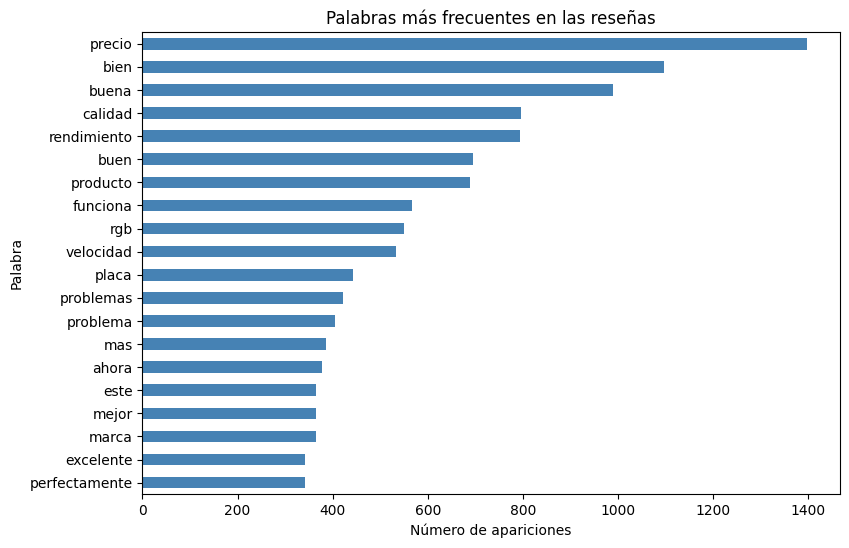

In [12]:
import matplotlib.pyplot as plt


palabras_comunes = [
    "a", "al", "con", "de", "del", "el",
    "en", "es", "esta", "las", "lo", "los",
    "más", "muy", "para", "pero", "por",
    "que", "se", "sin", "son", "todo",
    "un", "una", "y", "como",
    "ram", "memoria", "memorias",
]


palabras = (
    resenas_nlp["texto_limpio"]
    .str.split()
    .explode()
)


palabras = palabras.str.strip(
    ".,;:¡!¿?()[]{}\"'"
)


palabras = palabras[
    ~palabras.isin(palabras_comunes)
]


palabras = palabras[
    palabras.str.len() > 2
]


palabras_frecuentes = (
    palabras
    .value_counts()
    .head(20)
    .sort_values()
)


palabras_frecuentes.plot(
    kind="barh",
    figsize=(9, 6),
    color="steelblue",
)

plt.title("Palabras más frecuentes en las reseñas")
plt.xlabel("Número de apariciones")
plt.ylabel("Palabra")
plt.show()

El precio es el tema que más se repite. También aparecen muchas palabras positivas relacionadas con la calidad, el rendimiento y el funcionamiento del producto.

## Palabras según el tipo de reseña

Separamos las reseñas por sentimiento para comprobar qué palabras se repiten en cada grupo.

In [13]:
def contar_palabras_sentimiento(sentimiento):
    textos = resenas_nlp.loc[
        resenas_nlp["sentimiento"] == sentimiento,
        "texto_limpio",
    ]

    palabras = (
        textos
        .str.split()
        .explode()
        .str.strip(".,;:¡!¿?()[]{}\"'")
    )

    palabras = palabras[
        ~palabras.isin(palabras_comunes)
    ]

    palabras = palabras[
        palabras.str.len() > 2
    ]

    return palabras.value_counts().head(10)


palabras_positivas = contar_palabras_sentimiento(
    "positiva"
)

palabras_neutras = contar_palabras_sentimiento(
    "neutra"
)

palabras_negativas = contar_palabras_sentimiento(
    "negativa"
)


print("Palabras en reseñas positivas:")
print(palabras_positivas)

print("\nPalabras en reseñas neutras:")
print(palabras_neutras)

print("\nPalabras en reseñas negativas:")
print(palabras_negativas)

Palabras en reseñas positivas:
texto_limpio
precio         1316
bien           1019
buena           942
calidad         774
rendimiento     751
buen            672
producto        625
funciona        536
rgb             527
velocidad       495
Name: count, dtype: int64

Palabras en reseñas neutras:
texto_limpio
precio         63
bien           54
producto       37
buena          37
rendimiento    35
velocidad      29
mhz            26
placa          24
funciona       23
ddr4           22
Name: count, dtype: int64

Palabras en reseñas negativas:
texto_limpio
producto    27
bien        23
placa       20
precio      18
mas         14
tengo       13
dos         13
este        11
nada        11
mhz         10
Name: count, dtype: int64


En las reseñas positivas destacan el precio, la calidad y el rendimiento. En las negativas aparecen más referencias al producto, la placa y el precio. Como hay pocas reseñas negativas, sus resultados son menos representativos. Aquí solo contamos cuántas veces aparece cada palabra, sin analizar el significado de la frase completa.

## Palabras más usadas en pros y contras

Analizamos por separado las ventajas y los problemas escritos por los usuarios.

In [15]:
def contar_palabras_columna(nombre_columna):
    textos = resenas_nlp[nombre_columna].dropna().apply(limpiar_texto)

    palabras = (textos.str.split().explode().str.strip(".,;:¡!¿?()[]{}\"'"))

    palabras = palabras[~palabras.isin(palabras_comunes)]

    palabras = palabras[palabras.str.len() > 2]

    return palabras.value_counts().head(15)

palabras_pros = contar_palabras_columna("pros")
palabras_contras = contar_palabras_columna("contras")

print("Palabras más usadas en los pros:")
print(palabras_pros)

print("\nPalabras más usadas en los contras:")
print(palabras_contras)

Palabras más usadas en los pros:
pros
precio         685
calidad        413
buena          302
velocidad      264
buen           254
rendimiento    246
rgb            181
bien           143
fácil          109
relación       108
diseño         107
marca          103
funciona        88
instalación     80
capacidad       79
Name: count, dtype: int64

Palabras más usadas en los contras:
contras
ninguno    553
precio     492
ninguna    356
nada       319
momento    156
poco       129
rgb        128
algo       126
ser        102
puede       92
tiene       83
ahora       83
hay         80
mas         76
elevado     72
Name: count, dtype: int64


Los pros muestran resultados claros: destacan el precio, la calidad, la velocidad y el rendimiento.
En los contras, las palabras más frecuentes son ninguno, ninguna y nada. Esto indica que muchos usuarios rellenaron ese campo para decir que no encontraron problemas.

Contamos las respuestas completas más repetidas en `contras`. Así podemos distinguir entre usuarios que indican un problema y usuarios que escriben solamente “ninguno”, “ninguna” o “nada”.

In [17]:
contras_frecuentes = (resenas_nlp["contras"].dropna().apply(limpiar_texto).value_counts().head(15))

print(contras_frecuentes)

contras
ninguno                   335
ninguna                   213
nada                      164
precio                     79
ninguno.                   57
ninguna.                   31
el precio                  17
nada.                      15
de momento ninguno         14
no                         12
no tiene rgb               11
de momento ninguna         11
ninguno de momento         10
ninguno por el momento      9
precio.                     9
Name: count, dtype: int64


El resultado confirma que muchas personas usan contras para indicar que no encontraron ningún problema. Separamos estas respuestas para que no oculten los contras reales.

In [19]:
contras_limpios = (resenas_nlp["contras"].dropna().apply(limpiar_texto).str.strip(".,;:¡!¿?"))


respuestas_sin_contras = [
    "ninguno",
    "ninguna",
    "nada",
    "no",
    "de momento ninguno",
    "de momento ninguna",
    "ninguno de momento",
    "ninguno por el momento",
]


sin_contras = contras_limpios.isin(respuestas_sin_contras)


contras_reales = contras_limpios[~sin_contras]


print("Respuestas sin problemas:", sin_contras.sum())

print("Respuestas con algún contra:", len(contras_reales))

Respuestas sin problemas: 895
Respuestas con algún contra: 1961


El resultado indica que, entre las 2856 reseñas que tienen texto en contras, 895 dicen que no encontraron problemas y 1961 mencionan algún inconveniente.

Quitamos las respuestas que indican que no hay problemas y analizamos solamente los contras reales.

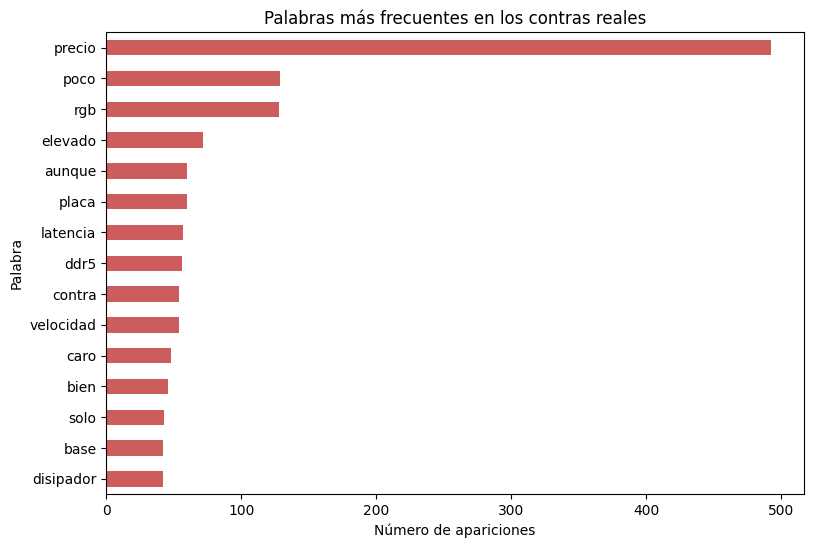

In [23]:
palabras_poco_utiles_contras = palabras_comunes + [
    "algo",
    "ahora",
    "hay",
    "mas",
    "momento",
    "nada",
    "ninguna",
    "ninguno",
    "puede",
    "ser",
    "tiene",
]

palabras_contras_reales = contras_reales.str.split().explode().str.strip(".,;:¡!¿?()[]{}\"'")

palabras_contras_reales = palabras_contras_reales[~palabras_contras_reales.isin(palabras_poco_utiles_contras)]

palabras_contras_reales = palabras_contras_reales[palabras_contras_reales.str.len() > 2]

contras_mas_frecuentes = palabras_contras_reales.value_counts().head(15).sort_values()

contras_mas_frecuentes.plot(kind="barh", figsize=(9, 6), color="indianred")

plt.title("Palabras más frecuentes en los contras reales")
plt.xlabel("Número de apariciones")
plt.ylabel("Palabra")
plt.show()

El precio es el problema más comentado por los usuarios. También aparecen algunas quejas sobre el RGB, la compatibilidad con la placa, la latencia, la velocidad y el disipador.

## Distribución de sentimientos

Mostramos cuántas reseñas hay de cada tipo para ver fácilmente la diferencia entre los tres grupos.

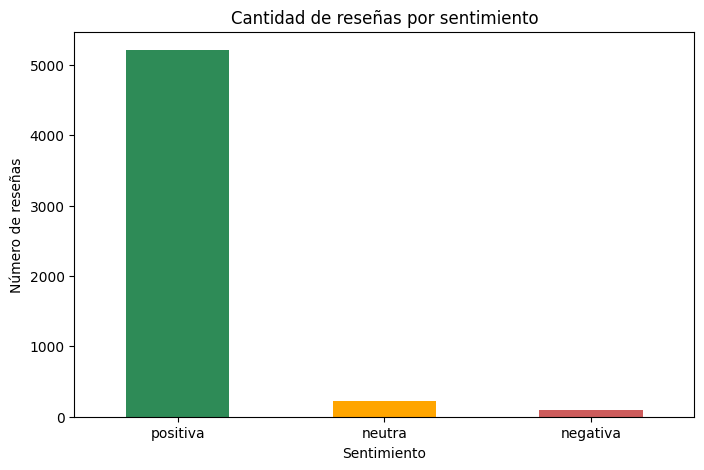

In [24]:
orden_sentimientos = ["positiva", "neutra", "negativa"]

cantidad_sentimientos = resenas_nlp["sentimiento"].value_counts().reindex(orden_sentimientos)

cantidad_sentimientos.plot(kind="bar", figsize=(8, 5), color=["seagreen", "orange", "indianred"])

plt.title("Cantidad de reseñas por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=0)
plt.show()

La mayoría de las reseñas son positivas. Las reseñas neutras y negativas son mucho menos frecuentes, por lo que los resultados están claramente desequilibrados.

## Conclusiones

- Se analizaron 5526 reseñas diferentes de memorias RAM.
- La mayoría de las valoraciones son positivas.
- El precio es uno de los temas más comentados.
- En los pros destacan la calidad, la velocidad y el rendimiento.
- El precio también es el contra más repetido.
- Muchos usuarios indican que no encontraron ningún problema.
- Este análisis cuenta palabras por separado y no interpreta frases completas.
- Las reseñas se clasificaron como positivas, neutras o negativas usando su valoración.

In [25]:
conn.close()

print("Conexión cerrada")

Conexión cerrada
